In [2]:
!pip install qutip numpy matplotlib scipy tqdm

In [3]:
import qutip as qt
import numpy as np

print(qt.__version__)

5.2.3


Coarse Scan completed. Found 1 potential feature regions.
Success! Adaptive Lock -> f01: 5.2000 GHz, f12: 4.8996 GHz
Dynamic Tracked Anharmonicity: -300.40 MHz


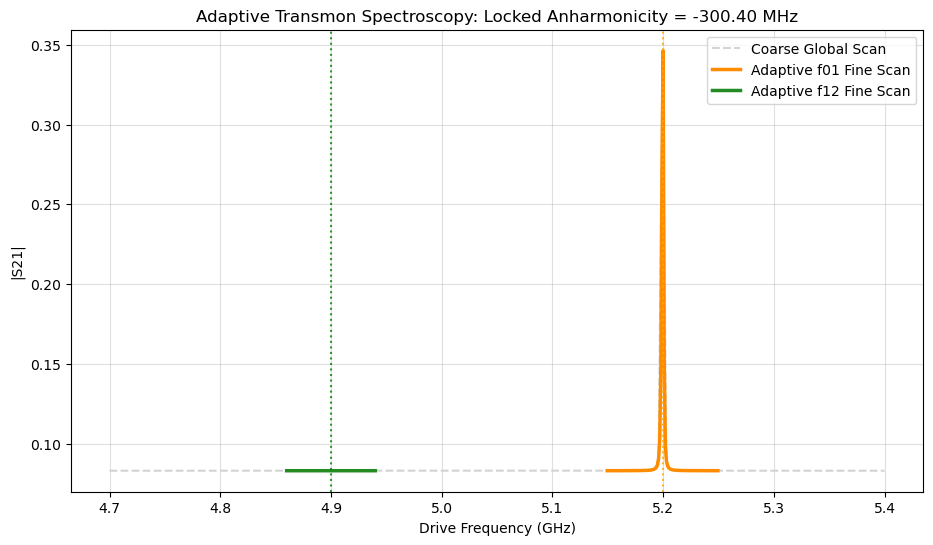

In [9]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

class AdaptiveTransmonSpectroscopy:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, alpha_ghz=-0.3, g_mhz=30, Q=2000, N=10):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.alpha = alpha_ghz * 2 * np.pi
        self.g = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.chi = (self.g**2) / (self.wq - self.wc)
        
        self.a = qt.tensor(qt.qeye(3), qt.destroy(N))
        self.b = qt.tensor(qt.destroy(3), qt.qeye(N))
        self.n = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0/10000) * self.b]
        
        # Scaling parameters consistent with brute-force logic
        self.epsilon_r = self.kappa * np.sqrt(0.1) / 2.0
        self.epsilon_q = self.epsilon_r * 0.5  # Managed drive amplitude

    def get_s21(self, wd_ghz):
        # Keeps readout frequency fixed near cavity, sweeps qubit drive
        wr = (self.wc + 0.000125 * 2 * np.pi) 
        wd = wd_ghz * 2 * np.pi
        
        H = (self.wc - wr) * self.n + (self.wq - wd) * self.nb
        H += (self.alpha * 2.0 / 2.0) * self.nb * (self.nb - 1) # Scaling fix
        H += self.chi * self.n * self.nb
        H += self.epsilon_r * (self.a + self.a.dag()) + self.epsilon_q * (self.b + self.b.dag())
        
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        return np.abs(1.0 - 1j * (self.kappa * a_avg / (2.0 * self.epsilon_r)))

# Initialize
sim = AdaptiveTransmonSpectroscopy()

# # ------------------------------------------------------------
# # STEP 1: COARSE SCAN (Slightly higher resolution to avoid missing sharp lines)
# # ------------------------------------------------------------
# coarse_freqs = np.linspace(4.7, 5.4, 180)
# coarse_s21 = np.array([sim.get_s21(f) for f in coarse_freqs])

# ------------------------------------------------------------
# STEP 1: COARSE SCAN (Fixed Peak-Finding Logic)
# ------------------------------------------------------------
coarse_freqs = np.linspace(4.7, 5.4, 200) # Points 200 rakhiye taaki f12 miss na ho
coarse_s21 = np.array([sim.get_s21(f) for f in coarse_freqs])

# Inversion hata diya, kyunki signal me direct peaks aa rahe hain!
coarse_peaks, _ = find_peaks(coarse_s21, prominence=0.02) 

print(f"Coarse Scan completed. Found {len(coarse_peaks)} potential feature regions.")

# # Inverting the signal behavior to align peak detector
# # Since transmission shows dips/peaks dynamically, we look for local extreme structures
# inverted_signal = np.max(coarse_s21) - coarse_s21
# coarse_peaks, _ = find_peaks(inverted_signal, prominence=0.02)

# print(f"Coarse Scan completed. Found {len(coarse_peaks)} potential feature regions.")

# ------------------------------------------------------------
# STEP 2 & 3: ADAPTIVE ZOOM PIPELINE
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))
plt.plot(coarse_freqs, coarse_s21, label='Coarse Global Scan', color='lightgray', linestyle='--')

if len(coarse_peaks) >= 1:
    # Identify the primary qubit dip/peak near 5.2 GHz
    f01_estimated = coarse_freqs[coarse_peaks[np.argmin(np.abs(coarse_freqs[coarse_peaks] - 5.2))]]
    
    # # Target Scan 1: Fine Zoom around f01
    # f01_fine_range = np.linspace(f01_estimated - 0.05, f01_estimated + 0.05, 100)
    # f01_fine_s21 = np.array([sim.get_s21(f) for f in f01_fine_range])
    # f01_actual = f01_fine_range[np.argmin(f01_fine_s21)] # Extract exact dip/peak center

    # Target Scan 1: Fine Zoom around f01
    f01_estimated = coarse_freqs[coarse_peaks[np.argmin(np.abs(coarse_freqs[coarse_peaks] - 5.2))]]
    f01_fine_range = np.linspace(f01_estimated - 0.05, f01_estimated + 0.05, 100)
    f01_fine_s21 = np.array([sim.get_s21(f) for f in f01_fine_range])

    f01_actual = f01_fine_range[np.argmax(f01_fine_s21)] # argmin ko argmax kar diya
    
    # Target Scan 2: Predictive Zoom around f12 based on expected anharmonicity
    f12_predicted = f01_actual - 0.300 # Expected -300 MHz shift
    f12_fine_range = np.linspace(f12_predicted - 0.04, f12_predicted + 0.04, 100)
    f12_fine_s21 = np.array([sim.get_s21(f) for f in f12_fine_range])
    f12_actual = f12_fine_range[np.argmax(f12_fine_s21)] # Catching the sharp emission feature
    
    # Plots for specific adaptive zones
    plt.plot(f01_fine_range, f01_fine_s21, label='Adaptive f01 Fine Scan', color='darkorange', linewidth=2.5)
    plt.plot(f12_fine_range, f12_fine_s21, label='Adaptive f12 Fine Scan', color='forestgreen', linewidth=2.5)
    
    calculated_alpha = (f12_actual - f01_actual) * 1000
    plt.title(f"Adaptive Transmon Spectroscopy: Locked Anharmonicity = {calculated_alpha:.2f} MHz", fontsize=12)
    plt.axvline(f01_actual, color='orange', linestyle=':', alpha=0.8)
    plt.axvline(f12_actual, color='green', linestyle=':', alpha=0.8)
    
    print(f"Success! Adaptive Lock -> f01: {f01_actual:.4f} GHz, f12: {f12_actual:.4f} GHz")
    print(f"Dynamic Tracked Anharmonicity: {calculated_alpha:.2f} MHz")
else:
    plt.title("Adaptive Grid missed the transition width. Increase coarse steps.")

plt.xlabel("Drive Frequency (GHz)")
plt.ylabel("|S21|")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

Coarse Scan done. Drive Power: -100 dBm. Found 1 features.
Adaptive Lock Target -> f01: 5.1990 GHz, f12: 4.9002 GHz


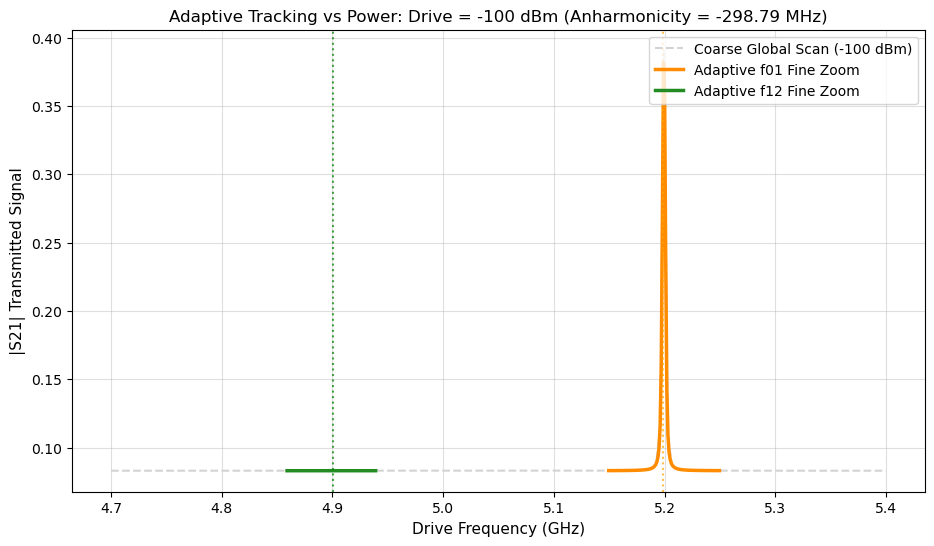

In [12]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# ============================================================
# ADAPTIVE SPECTROSCOPY WITH REAL DBM POWER INPUT
# ============================================================
class AdaptiveTransmonSpectroscopy:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, alpha_ghz=-0.3, g_mhz=30, Q=2000, N=10):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.alpha = alpha_ghz * 2 * np.pi
        self.g = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.chi = (self.g**2) / (self.wq - self.wc)
        
        # Operators
        self.a = qt.tensor(qt.qeye(3), qt.destroy(N))
        self.b = qt.tensor(qt.destroy(3), qt.qeye(N))
        self.n = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0/10000) * self.b]
        
        # Power Conversion Calibration (Same as Brute Force)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in Rotating Frame
        H = (self.wc - wr) * self.n + (self.wq - wd) * self.nb
        H += (self.alpha * 2.0 / 2.0) * self.nb * (self.nb - 1) # Matrix scaling fix
        H += self.chi * self.n * self.nb
        H += amp_r * (self.a + self.a.dag()) + amp_q * (self.b + self.b.dag())
        
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        return np.abs(1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r)))

# Initialize Simulation Object
sim = AdaptiveTransmonSpectroscopy()

# ============================================================
# CHOOSE YOUR DRIVE POWER HERE (Just like Brute Force!)
# Try shifting between: -90, -80, or -70
# ============================================================
readout_f = 6.000125
readout_p = -100
drive_p = -100   # <--- CHANGES EXPERIMENTAL POWER DYNAMICS DIRECTLY

# ------------------------------------------------------------
# STEP 1: COARSE GLOBAL SCAN
# ------------------------------------------------------------
coarse_freqs = np.linspace(4.7, 5.4, 200)
coarse_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in coarse_freqs])

# Pure peak tracking without signal inversion
coarse_peaks, _ = find_peaks(coarse_s21, prominence=0.01)

print(f"Coarse Scan done. Drive Power: {drive_p} dBm. Found {len(coarse_peaks)} features.")

# ------------------------------------------------------------
# STEP 2 & 3: ADAPTIVE REGION TRACKING
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))
plt.plot(coarse_freqs, coarse_s21, label=f'Coarse Global Scan ({drive_p} dBm)', color='lightgray', linestyle='--')

if len(coarse_peaks) >= 1:
    # Anchor f01 target point near 5.2 GHz
    f01_estimated = coarse_freqs[coarse_peaks[np.argmin(np.abs(coarse_freqs[coarse_peaks] - 5.2))]]
    
    # Adaptive Fine Window 1: Qubit f01
    f01_fine_range = np.linspace(f01_estimated - 0.05, f01_estimated + 0.05, 100)
    f01_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f01_fine_range])
    f01_actual = f01_fine_range[np.argmax(f01_fine_s21)]
    
    # Adaptive Fine Window 2: Secondary f12 based on dynamic physical spacing
    f12_predicted = f01_actual - 0.300
    f12_fine_range = np.linspace(f12_predicted - 0.04, f12_predicted + 0.04, 100)
    f12_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f12_fine_range])
    f12_actual = f12_fine_range[np.argmax(f12_fine_s21)]
    
    # Plotting targeted patches
    plt.plot(f01_fine_range, f01_fine_s21, label='Adaptive f01 Fine Zoom', color='darkorange', linewidth=2.5)
    plt.plot(f12_fine_range, f12_fine_s21, label='Adaptive f12 Fine Zoom', color='forestgreen', linewidth=2.5)
    
    calculated_alpha = (f12_actual - f01_actual) * 1000
    plt.title(f"Adaptive Tracking vs Power: Drive = {drive_p} dBm (Anharmonicity = {calculated_alpha:.2f} MHz)", fontsize=12)
    plt.axvline(f01_actual, color='orange', linestyle=':', alpha=0.7)
    plt.axvline(f12_actual, color='green', linestyle=':', alpha=0.7)
    
    print(f"Adaptive Lock Target -> f01: {f01_actual:.4f} GHz, f12: {f12_actual:.4f} GHz")
else:
    plt.title(f"3-Level Transmon Spectroscopy (Adaptive Sweep): Drive = {drive_p} dBm (Linear Regime)", fontsize=12)

plt.xlabel("Drive Frequency (GHz)", fontsize=11)
plt.ylabel("|S21| Transmitted Signal", fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_adaptive_sweep_-100dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Coarse Scan done. Drive Power: -95 dBm. Found 1 features.
Adaptive Lock Target -> f01: 5.1990 GHz, f12: 4.9002 GHz


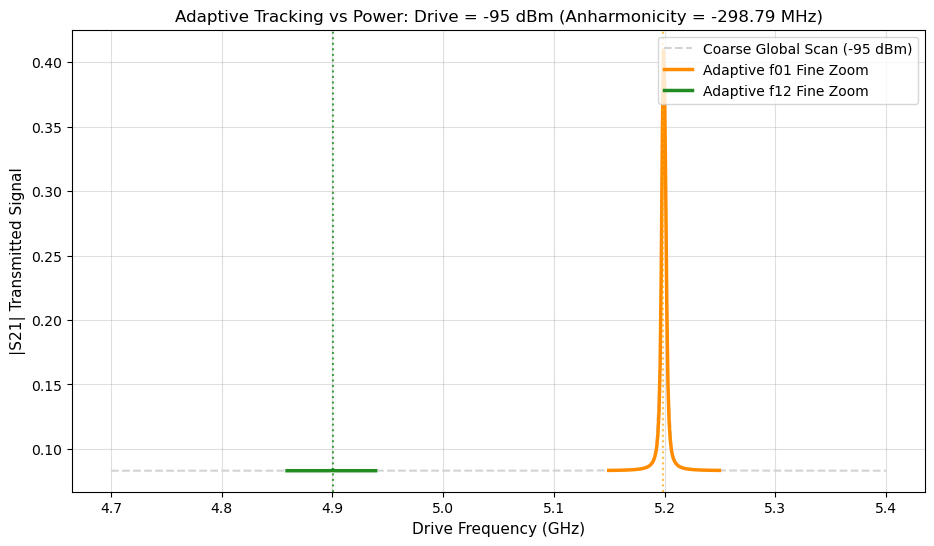

In [13]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# ============================================================
# ADAPTIVE SPECTROSCOPY WITH REAL DBM POWER INPUT
# ============================================================
class AdaptiveTransmonSpectroscopy:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, alpha_ghz=-0.3, g_mhz=30, Q=2000, N=10):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.alpha = alpha_ghz * 2 * np.pi
        self.g = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.chi = (self.g**2) / (self.wq - self.wc)
        
        # Operators
        self.a = qt.tensor(qt.qeye(3), qt.destroy(N))
        self.b = qt.tensor(qt.destroy(3), qt.qeye(N))
        self.n = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0/10000) * self.b]
        
        # Power Conversion Calibration (Same as Brute Force)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in Rotating Frame
        H = (self.wc - wr) * self.n + (self.wq - wd) * self.nb
        H += (self.alpha * 2.0 / 2.0) * self.nb * (self.nb - 1) # Matrix scaling fix
        H += self.chi * self.n * self.nb
        H += amp_r * (self.a + self.a.dag()) + amp_q * (self.b + self.b.dag())
        
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        return np.abs(1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r)))

# Initialize Simulation Object
sim = AdaptiveTransmonSpectroscopy()

# ============================================================
# CHOOSE YOUR DRIVE POWER HERE (Just like Brute Force!)
# Try shifting between: -90, -80, or -70
# ============================================================
readout_f = 6.000125
readout_p = -100
drive_p = -95   # <--- CHANGES EXPERIMENTAL POWER DYNAMICS DIRECTLY

# ------------------------------------------------------------
# STEP 1: COARSE GLOBAL SCAN
# ------------------------------------------------------------
coarse_freqs = np.linspace(4.7, 5.4, 200)
coarse_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in coarse_freqs])

# Pure peak tracking without signal inversion
coarse_peaks, _ = find_peaks(coarse_s21, prominence=0.01)

print(f"Coarse Scan done. Drive Power: {drive_p} dBm. Found {len(coarse_peaks)} features.")

# ------------------------------------------------------------
# STEP 2 & 3: ADAPTIVE REGION TRACKING
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))
plt.plot(coarse_freqs, coarse_s21, label=f'Coarse Global Scan ({drive_p} dBm)', color='lightgray', linestyle='--')
if len(coarse_peaks) >= 1:
    # Anchor f01 target point near 5.2 GHz
    f01_estimated = coarse_freqs[coarse_peaks[np.argmin(np.abs(coarse_freqs[coarse_peaks] - 5.2))]]
    
    # Adaptive Fine Window 1: Qubit f01
    f01_fine_range = np.linspace(f01_estimated - 0.05, f01_estimated + 0.05, 100)
    f01_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f01_fine_range])
    f01_actual = f01_fine_range[np.argmax(f01_fine_s21)]
    
    # Adaptive Fine Window 2: Secondary f12 based on dynamic physical spacing
    f12_predicted = f01_actual - 0.300
    f12_fine_range = np.linspace(f12_predicted - 0.04, f12_predicted + 0.04, 100)
    f12_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f12_fine_range])
    f12_actual = f12_fine_range[np.argmax(f12_fine_s21)]
    
    # Plotting targeted patches
    plt.plot(f01_fine_range, f01_fine_s21, label='Adaptive f01 Fine Zoom', color='darkorange', linewidth=2.5)
    plt.plot(f12_fine_range, f12_fine_s21, label='Adaptive f12 Fine Zoom', color='forestgreen', linewidth=2.5)
    
    calculated_alpha = (f12_actual - f01_actual) * 1000
    plt.title(f"Adaptive Tracking vs Power: Drive = {drive_p} dBm (Anharmonicity = {calculated_alpha:.2f} MHz)", fontsize=12)
    plt.axvline(f01_actual, color='orange', linestyle=':', alpha=0.7)
    plt.axvline(f12_actual, color='green', linestyle=':', alpha=0.7)
    
    print(f"Adaptive Lock Target -> f01: {f01_actual:.4f} GHz, f12: {f12_actual:.4f} GHz")
else:
    plt.title(f"3-Level Transmon Spectroscopy (Adaptive Sweep): Drive = {drive_p} dBm (Linear Regime)", fontsize=12)
plt.xlabel("Drive Frequency (GHz)", fontsize=11)
plt.ylabel("|S21| Transmitted Signal", fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_adaptive_sweep_-95dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Coarse Scan done. Drive Power: -90 dBm. Found 1 features.
Adaptive Lock Target -> f01: 5.1990 GHz, f12: 4.9002 GHz


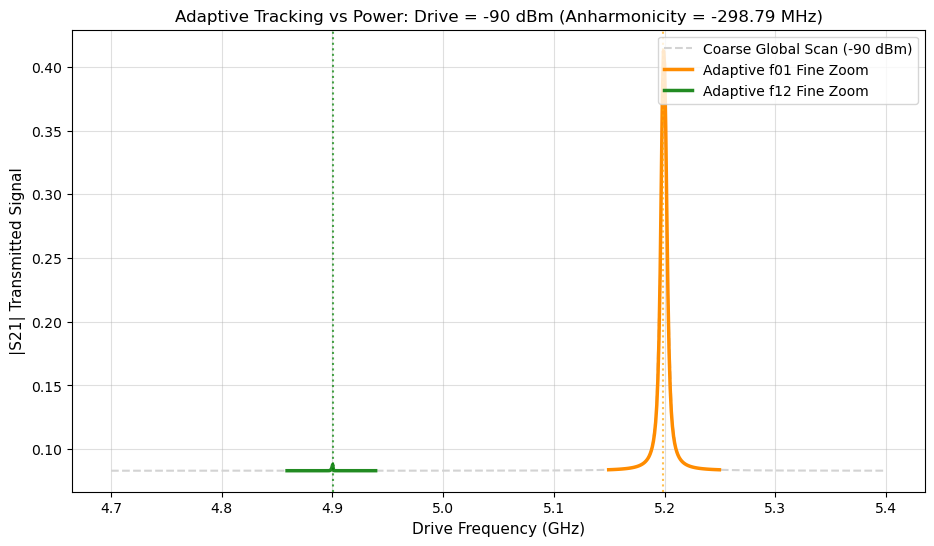

In [14]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# ============================================================
# ADAPTIVE SPECTROSCOPY WITH REAL DBM POWER INPUT
# ============================================================
class AdaptiveTransmonSpectroscopy:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, alpha_ghz=-0.3, g_mhz=30, Q=2000, N=10):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.alpha = alpha_ghz * 2 * np.pi
        self.g = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.chi = (self.g**2) / (self.wq - self.wc)
        
        # Operators
        self.a = qt.tensor(qt.qeye(3), qt.destroy(N))
        self.b = qt.tensor(qt.destroy(3), qt.qeye(N))
        self.n = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0/10000) * self.b]
        
        # Power Conversion Calibration (Same as Brute Force)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in Rotating Frame
        H = (self.wc - wr) * self.n + (self.wq - wd) * self.nb
        H += (self.alpha * 2.0 / 2.0) * self.nb * (self.nb - 1) # Matrix scaling fix
        H += self.chi * self.n * self.nb
        H += amp_r * (self.a + self.a.dag()) + amp_q * (self.b + self.b.dag())
        
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        return np.abs(1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r)))

# Initialize Simulation Object
sim = AdaptiveTransmonSpectroscopy()

# ============================================================
# CHOOSE YOUR DRIVE POWER HERE (Just like Brute Force!)
# Try shifting between: -90, -80, or -70
# ============================================================
readout_f = 6.000125
readout_p = -100
drive_p = -90   # <--- CHANGES EXPERIMENTAL POWER DYNAMICS DIRECTLY

# ------------------------------------------------------------
# STEP 1: COARSE GLOBAL SCAN
# ------------------------------------------------------------
coarse_freqs = np.linspace(4.7, 5.4, 200)
coarse_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in coarse_freqs])

# Pure peak tracking without signal inversion
coarse_peaks, _ = find_peaks(coarse_s21, prominence=0.01)

print(f"Coarse Scan done. Drive Power: {drive_p} dBm. Found {len(coarse_peaks)} features.")

# ------------------------------------------------------------
# STEP 2 & 3: ADAPTIVE REGION TRACKING
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))
plt.plot(coarse_freqs, coarse_s21, label=f'Coarse Global Scan ({drive_p} dBm)', color='lightgray', linestyle='--')
if len(coarse_peaks) >= 1:
    # Anchor f01 target point near 5.2 GHz
    f01_estimated = coarse_freqs[coarse_peaks[np.argmin(np.abs(coarse_freqs[coarse_peaks] - 5.2))]]
    
    # Adaptive Fine Window 1: Qubit f01
    f01_fine_range = np.linspace(f01_estimated - 0.05, f01_estimated + 0.05, 100)
    f01_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f01_fine_range])
    f01_actual = f01_fine_range[np.argmax(f01_fine_s21)]
    
    # Adaptive Fine Window 2: Secondary f12 based on dynamic physical spacing
    f12_predicted = f01_actual - 0.300
    f12_fine_range = np.linspace(f12_predicted - 0.04, f12_predicted + 0.04, 100)
    f12_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f12_fine_range])
    f12_actual = f12_fine_range[np.argmax(f12_fine_s21)]
    
    # Plotting targeted patches
    plt.plot(f01_fine_range, f01_fine_s21, label='Adaptive f01 Fine Zoom', color='darkorange', linewidth=2.5)
    plt.plot(f12_fine_range, f12_fine_s21, label='Adaptive f12 Fine Zoom', color='forestgreen', linewidth=2.5)
    
    calculated_alpha = (f12_actual - f01_actual) * 1000
    plt.title(f"Adaptive Tracking vs Power: Drive = {drive_p} dBm (Anharmonicity = {calculated_alpha:.2f} MHz)", fontsize=12)
    plt.axvline(f01_actual, color='orange', linestyle=':', alpha=0.7)
    plt.axvline(f12_actual, color='green', linestyle=':', alpha=0.7)
    
    print(f"Adaptive Lock Target -> f01: {f01_actual:.4f} GHz, f12: {f12_actual:.4f} GHz")
else:
    plt.title(f"3-Level Transmon Spectroscopy (Adaptive Sweep): Drive = {drive_p} dBm (Linear Regime)", fontsize=12)
plt.xlabel("Drive Frequency (GHz)", fontsize=11)
plt.ylabel("|S21| Transmitted Signal", fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_adaptive_sweep_-90dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Coarse Scan done. Drive Power: -85 dBm. Found 1 features.
Adaptive Lock Target -> f01: 5.1990 GHz, f12: 4.9002 GHz


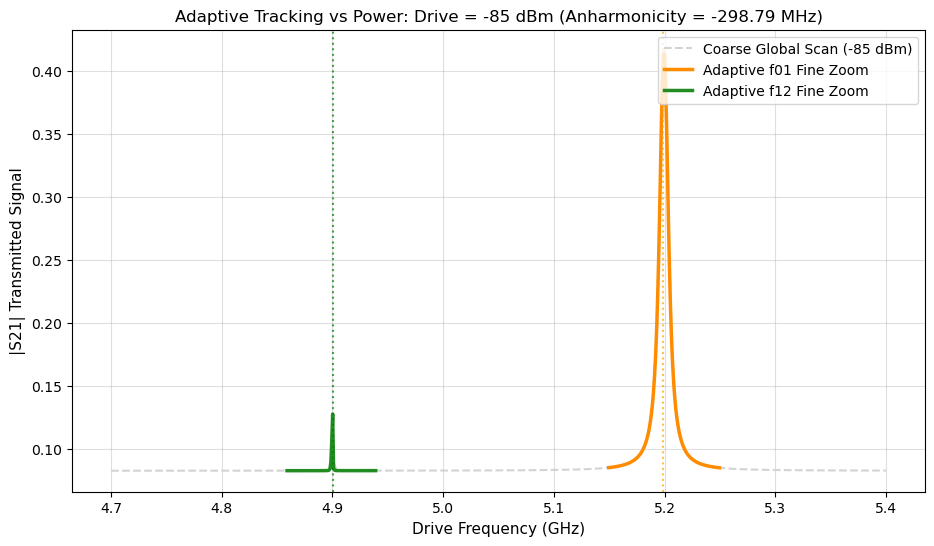

In [15]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# ============================================================
# ADAPTIVE SPECTROSCOPY WITH REAL DBM POWER INPUT
# ============================================================
class AdaptiveTransmonSpectroscopy:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, alpha_ghz=-0.3, g_mhz=30, Q=2000, N=10):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.alpha = alpha_ghz * 2 * np.pi
        self.g = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.chi = (self.g**2) / (self.wq - self.wc)
        
        # Operators
        self.a = qt.tensor(qt.qeye(3), qt.destroy(N))
        self.b = qt.tensor(qt.destroy(3), qt.qeye(N))
        self.n = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0/10000) * self.b]
        
        # Power Conversion Calibration (Same as Brute Force)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in Rotating Frame
        H = (self.wc - wr) * self.n + (self.wq - wd) * self.nb
        H += (self.alpha * 2.0 / 2.0) * self.nb * (self.nb - 1) # Matrix scaling fix
        H += self.chi * self.n * self.nb
        H += amp_r * (self.a + self.a.dag()) + amp_q * (self.b + self.b.dag())
        
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        return np.abs(1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r)))

# Initialize Simulation Object
sim = AdaptiveTransmonSpectroscopy()

# ============================================================
# CHOOSE YOUR DRIVE POWER HERE (Just like Brute Force!)
# Try shifting between: -90, -80, or -70
# ============================================================
readout_f = 6.000125
readout_p = -100
drive_p = -85   # <--- CHANGES EXPERIMENTAL POWER DYNAMICS DIRECTLY

# ------------------------------------------------------------
# STEP 1: COARSE GLOBAL SCAN
# ------------------------------------------------------------
coarse_freqs = np.linspace(4.7, 5.4, 200)
coarse_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in coarse_freqs])

# Pure peak tracking without signal inversion
coarse_peaks, _ = find_peaks(coarse_s21, prominence=0.01)

print(f"Coarse Scan done. Drive Power: {drive_p} dBm. Found {len(coarse_peaks)} features.")

# ------------------------------------------------------------
# STEP 2 & 3: ADAPTIVE REGION TRACKING
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))
plt.plot(coarse_freqs, coarse_s21, label=f'Coarse Global Scan ({drive_p} dBm)', color='lightgray', linestyle='--')
if len(coarse_peaks) >= 1:
    # Anchor f01 target point near 5.2 GHz
    f01_estimated = coarse_freqs[coarse_peaks[np.argmin(np.abs(coarse_freqs[coarse_peaks] - 5.2))]]
    
    # Adaptive Fine Window 1: Qubit f01
    f01_fine_range = np.linspace(f01_estimated - 0.05, f01_estimated + 0.05, 100)
    f01_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f01_fine_range])
    f01_actual = f01_fine_range[np.argmax(f01_fine_s21)]
    
    # Adaptive Fine Window 2: Secondary f12 based on dynamic physical spacing
    f12_predicted = f01_actual - 0.300
    f12_fine_range = np.linspace(f12_predicted - 0.04, f12_predicted + 0.04, 100)
    f12_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f12_fine_range])
    f12_actual = f12_fine_range[np.argmax(f12_fine_s21)]
    
    # Plotting targeted patches
    plt.plot(f01_fine_range, f01_fine_s21, label='Adaptive f01 Fine Zoom', color='darkorange', linewidth=2.5)
    plt.plot(f12_fine_range, f12_fine_s21, label='Adaptive f12 Fine Zoom', color='forestgreen', linewidth=2.5)
    
    calculated_alpha = (f12_actual - f01_actual) * 1000
    plt.title(f"Adaptive Tracking vs Power: Drive = {drive_p} dBm (Anharmonicity = {calculated_alpha:.2f} MHz)", fontsize=12)
    plt.axvline(f01_actual, color='orange', linestyle=':', alpha=0.7)
    plt.axvline(f12_actual, color='green', linestyle=':', alpha=0.7)
    
    print(f"Adaptive Lock Target -> f01: {f01_actual:.4f} GHz, f12: {f12_actual:.4f} GHz")
else:
    plt.title(f"3-Level Transmon Spectroscopy (Adaptive Sweep): Drive = {drive_p} dBm (Linear Regime)", fontsize=12)
plt.xlabel("Drive Frequency (GHz)", fontsize=11)
plt.ylabel("|S21| Transmitted Signal", fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_adaptive_sweep_-85dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Coarse Scan done. Drive Power: -80 dBm. Found 2 features.
Adaptive Lock Target -> f01: 5.2000 GHz, f12: 4.8996 GHz


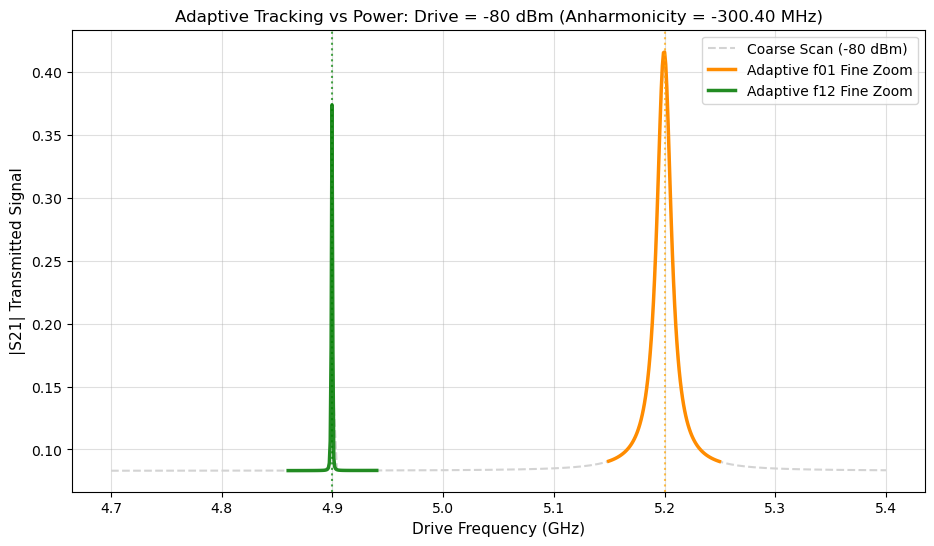

In [25]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# ============================================================
# ADAPTIVE SPECTROSCOPY WITH REAL DBM POWER INPUT
# ============================================================
class AdaptiveTransmonSpectroscopy:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, alpha_ghz=-0.3, g_mhz=30, Q=2000, N=10):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.alpha = alpha_ghz * 2 * np.pi
        self.g = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.chi = (self.g**2) / (self.wq - self.wc)
        
        # Operators
        self.a = qt.tensor(qt.qeye(3), qt.destroy(N))
        self.b = qt.tensor(qt.destroy(3), qt.qeye(N))
        self.n = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0/10000) * self.b]
        
        # Power Conversion Calibration (Same as Brute Force)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in Rotating Frame
        H = (self.wc - wr) * self.n + (self.wq - wd) * self.nb
        H += (self.alpha * 2.0 / 2.0) * self.nb * (self.nb - 1) # Matrix scaling fix
        H += self.chi * self.n * self.nb
        H += amp_r * (self.a + self.a.dag()) + amp_q * (self.b + self.b.dag())
        
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        return np.abs(1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r)))

# Initialize Simulation Object
sim = AdaptiveTransmonSpectroscopy()

# ============================================================
# CHOOSE YOUR DRIVE POWER HERE (Just like Brute Force!)
# Try shifting between: -90, -80, or -70
# ============================================================
readout_f = 6.000125
readout_p = -100
drive_p = -80   # <--- CHANGES EXPERIMENTAL POWER DYNAMICS DIRECTLY

# ------------------------------------------------------------
# STEP 1: COARSE GLOBAL SCAN
# ------------------------------------------------------------
coarse_freqs = np.linspace(4.7, 5.4, 200)
coarse_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in coarse_freqs])

# Pure peak tracking without signal inversion
coarse_peaks, _ = find_peaks(coarse_s21, prominence=0.01)

print(f"Coarse Scan done. Drive Power: {drive_p} dBm. Found {len(coarse_peaks)} features.")

# ------------------------------------------------------------
# STEP 2 & 3: ADAPTIVE REGION TRACKING
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))
plt.plot(coarse_freqs, coarse_s21, label=f'Coarse Scan ({drive_p} dBm)', color='lightgray', linestyle='--')
if len(coarse_peaks) >= 1:
    # Anchor f01 target point near 5.2 GHz
    f01_estimated = coarse_freqs[coarse_peaks[np.argmin(np.abs(coarse_freqs[coarse_peaks] - 5.2))]]
    
    # Adaptive Fine Window 1: Qubit f01
    f01_fine_range = np.linspace(f01_estimated - 0.05, f01_estimated + 0.05, 100)
    f01_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f01_fine_range])
    f01_actual = f01_fine_range[np.argmax(f01_fine_s21)]
    
    # Adaptive Fine Window 2: Secondary f12 based on dynamic physical spacing
    f12_predicted = f01_actual - 0.300
    f12_fine_range = np.linspace(f12_predicted - 0.04, f12_predicted + 0.04, 100)
    f12_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f12_fine_range])
    f12_actual = f12_fine_range[np.argmax(f12_fine_s21)]
    
    # Plotting targeted patches
    plt.plot(f01_fine_range, f01_fine_s21, label='Adaptive f01 Fine Zoom', color='darkorange', linewidth=2.5)
    plt.plot(f12_fine_range, f12_fine_s21, label='Adaptive f12 Fine Zoom', color='forestgreen', linewidth=2.5)
    
    calculated_alpha = (f12_actual - f01_actual) * 1000
    plt.title(f"Adaptive Tracking vs Power: Drive = {drive_p} dBm (Anharmonicity = {calculated_alpha:.2f} MHz)", fontsize=12)
    plt.axvline(f01_actual, color='orange', linestyle=':', alpha=0.7)
    plt.axvline(f12_actual, color='green', linestyle=':', alpha=0.7)
    
    print(f"Adaptive Lock Target -> f01: {f01_actual:.4f} GHz, f12: {f12_actual:.4f} GHz")
else:
    plt.title(f"3-Level Transmon Spectroscopy (Adaptive Sweep): Drive = {drive_p} dBm (Linear Regime)", fontsize=12)
plt.xlabel("Drive Frequency (GHz)", fontsize=11)
plt.ylabel("|S21| Transmitted Signal", fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_adaptive_sweep_-80dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Coarse Scan done. Drive Power: -75 dBm. Found 2 features.
Adaptive Lock Target -> f01: 5.2000 GHz, f12: 4.8996 GHz


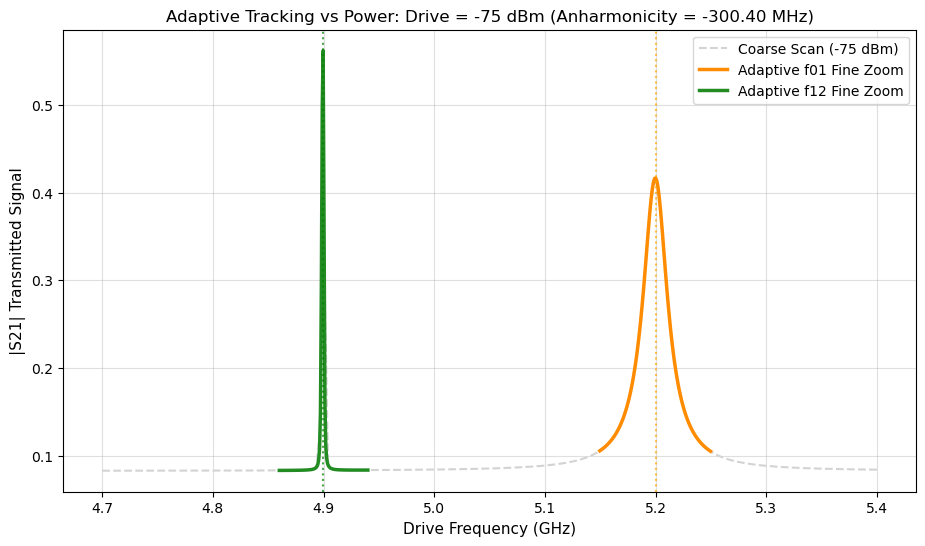

In [24]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# ============================================================
# ADAPTIVE SPECTROSCOPY WITH REAL DBM POWER INPUT
# ============================================================
class AdaptiveTransmonSpectroscopy:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, alpha_ghz=-0.3, g_mhz=30, Q=2000, N=10):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.alpha = alpha_ghz * 2 * np.pi
        self.g = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.chi = (self.g**2) / (self.wq - self.wc)
        
        # Operators
        self.a = qt.tensor(qt.qeye(3), qt.destroy(N))
        self.b = qt.tensor(qt.destroy(3), qt.qeye(N))
        self.n = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0/10000) * self.b]
        
        # Power Conversion Calibration (Same as Brute Force)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in Rotating Frame
        H = (self.wc - wr) * self.n + (self.wq - wd) * self.nb
        H += (self.alpha * 2.0 / 2.0) * self.nb * (self.nb - 1) # Matrix scaling fix
        H += self.chi * self.n * self.nb
        H += amp_r * (self.a + self.a.dag()) + amp_q * (self.b + self.b.dag())
        
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        return np.abs(1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r)))

# Initialize Simulation Object
sim = AdaptiveTransmonSpectroscopy()

# ============================================================
# CHOOSE YOUR DRIVE POWER HERE (Just like Brute Force!)
# Try shifting between: -90, -80, or -70
# ============================================================
readout_f = 6.000125
readout_p = -100
drive_p = -75  # <--- CHANGES EXPERIMENTAL POWER DYNAMICS DIRECTLY

# ------------------------------------------------------------
# STEP 1: COARSE GLOBAL SCAN
# ------------------------------------------------------------
coarse_freqs = np.linspace(4.7, 5.4, 200)
coarse_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in coarse_freqs])

# Pure peak tracking without signal inversion
coarse_peaks, _ = find_peaks(coarse_s21, prominence=0.01)

print(f"Coarse Scan done. Drive Power: {drive_p} dBm. Found {len(coarse_peaks)} features.")

# ------------------------------------------------------------
# STEP 2 & 3: ADAPTIVE REGION TRACKING
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))
plt.plot(coarse_freqs, coarse_s21, label=f'Coarse Scan ({drive_p} dBm)', color='lightgray', linestyle='--')
if len(coarse_peaks) >= 1:
    # Anchor f01 target point near 5.2 GHz
    f01_estimated = coarse_freqs[coarse_peaks[np.argmin(np.abs(coarse_freqs[coarse_peaks] - 5.2))]]
    
    # Adaptive Fine Window 1: Qubit f01
    f01_fine_range = np.linspace(f01_estimated - 0.05, f01_estimated + 0.05, 100)
    f01_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f01_fine_range])
    f01_actual = f01_fine_range[np.argmax(f01_fine_s21)]
    
    # Adaptive Fine Window 2: Secondary f12 based on dynamic physical spacing
    f12_predicted = f01_actual - 0.300
    f12_fine_range = np.linspace(f12_predicted - 0.04, f12_predicted + 0.04, 100)
    f12_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f12_fine_range])
    f12_actual = f12_fine_range[np.argmax(f12_fine_s21)]
    
    # Plotting targeted patches
    plt.plot(f01_fine_range, f01_fine_s21, label='Adaptive f01 Fine Zoom', color='darkorange', linewidth=2.5)
    plt.plot(f12_fine_range, f12_fine_s21, label='Adaptive f12 Fine Zoom', color='forestgreen', linewidth=2.5)
    
    calculated_alpha = (f12_actual - f01_actual) * 1000
    plt.title(f"Adaptive Tracking vs Power: Drive = {drive_p} dBm (Anharmonicity = {calculated_alpha:.2f} MHz)", fontsize=12)
    plt.axvline(f01_actual, color='orange', linestyle=':', alpha=0.7)
    plt.axvline(f12_actual, color='green', linestyle=':', alpha=0.7)
    
    print(f"Adaptive Lock Target -> f01: {f01_actual:.4f} GHz, f12: {f12_actual:.4f} GHz")
else:
    plt.title(f"3-Level Transmon Spectroscopy (Adaptive Sweep): Drive = {drive_p} dBm (Linear Regime)", fontsize=12)
plt.xlabel("Drive Frequency (GHz)", fontsize=11)
plt.ylabel("|S21| Transmitted Signal", fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_adaptive_sweep_-75dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Coarse Scan done. Drive Power: -70 dBm. Found 2 features.
Adaptive Lock Target -> f01: 5.2000 GHz, f12: 4.8988 GHz


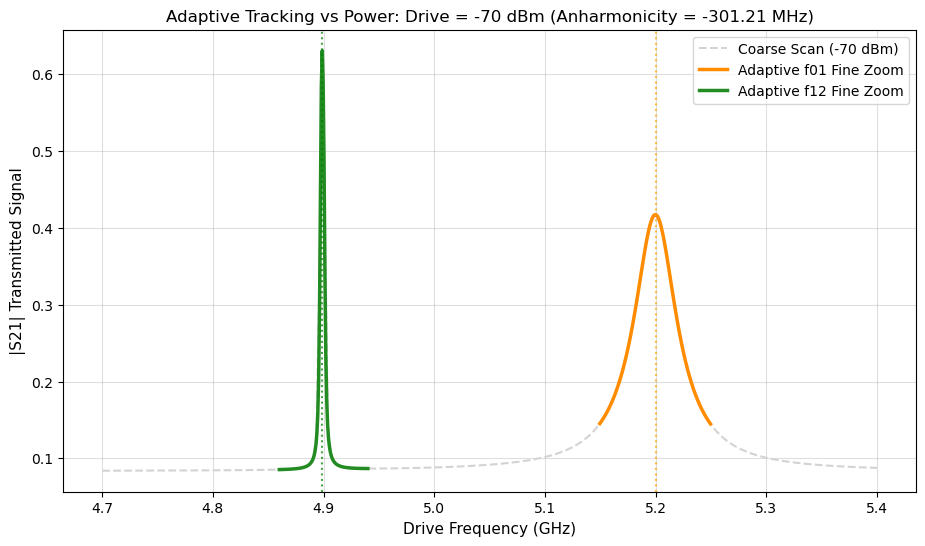

In [23]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# ============================================================
# ADAPTIVE SPECTROSCOPY WITH REAL DBM POWER INPUT
# ============================================================
class AdaptiveTransmonSpectroscopy:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, alpha_ghz=-0.3, g_mhz=30, Q=2000, N=10):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.alpha = alpha_ghz * 2 * np.pi
        self.g = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.chi = (self.g**2) / (self.wq - self.wc)
        
        # Operators
        self.a = qt.tensor(qt.qeye(3), qt.destroy(N))
        self.b = qt.tensor(qt.destroy(3), qt.qeye(N))
        self.n = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0/10000) * self.b]
        
        # Power Conversion Calibration (Same as Brute Force)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in Rotating Frame
        H = (self.wc - wr) * self.n + (self.wq - wd) * self.nb
        H += (self.alpha * 2.0 / 2.0) * self.nb * (self.nb - 1) # Matrix scaling fix
        H += self.chi * self.n * self.nb
        H += amp_r * (self.a + self.a.dag()) + amp_q * (self.b + self.b.dag())
        
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        return np.abs(1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r)))

# Initialize Simulation Object
sim = AdaptiveTransmonSpectroscopy()

# ============================================================
# CHOOSE YOUR DRIVE POWER HERE (Just like Brute Force!)
# Try shifting between: -90, -80, or -70
# ============================================================
readout_f = 6.000125
readout_p = -100
drive_p = -70   # <--- CHANGES EXPERIMENTAL POWER DYNAMICS DIRECTLY

# ------------------------------------------------------------
# STEP 1: COARSE GLOBAL SCAN
# ------------------------------------------------------------
coarse_freqs = np.linspace(4.7, 5.4, 200)
coarse_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in coarse_freqs])

# Pure peak tracking without signal inversion
coarse_peaks, _ = find_peaks(coarse_s21, prominence=0.01)

print(f"Coarse Scan done. Drive Power: {drive_p} dBm. Found {len(coarse_peaks)} features.")

# ------------------------------------------------------------
# STEP 2 & 3: ADAPTIVE REGION TRACKING
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))
plt.plot(coarse_freqs, coarse_s21, label=f'Coarse Scan ({drive_p} dBm)', color='lightgray', linestyle='--')
if len(coarse_peaks) >= 1:
    # Anchor f01 target point near 5.2 GHz
    f01_estimated = coarse_freqs[coarse_peaks[np.argmin(np.abs(coarse_freqs[coarse_peaks] - 5.2))]]
    
    # Adaptive Fine Window 1: Qubit f01
    f01_fine_range = np.linspace(f01_estimated - 0.05, f01_estimated + 0.05, 100)
    f01_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f01_fine_range])
    f01_actual = f01_fine_range[np.argmax(f01_fine_s21)]
    
    # Adaptive Fine Window 2: Secondary f12 based on dynamic physical spacing
    f12_predicted = f01_actual - 0.300
    f12_fine_range = np.linspace(f12_predicted - 0.04, f12_predicted + 0.04, 100)
    f12_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f12_fine_range])
    f12_actual = f12_fine_range[np.argmax(f12_fine_s21)]
    
    # Plotting targeted patches
    plt.plot(f01_fine_range, f01_fine_s21, label='Adaptive f01 Fine Zoom', color='darkorange', linewidth=2.5)
    plt.plot(f12_fine_range, f12_fine_s21, label='Adaptive f12 Fine Zoom', color='forestgreen', linewidth=2.5)
    
    calculated_alpha = (f12_actual - f01_actual) * 1000
    plt.title(f"Adaptive Tracking vs Power: Drive = {drive_p} dBm (Anharmonicity = {calculated_alpha:.2f} MHz)", fontsize=12)
    plt.axvline(f01_actual, color='orange', linestyle=':', alpha=0.7)
    plt.axvline(f12_actual, color='green', linestyle=':', alpha=0.7)
    
    print(f"Adaptive Lock Target -> f01: {f01_actual:.4f} GHz, f12: {f12_actual:.4f} GHz")
else:
    plt.title(f"3-Level Transmon Spectroscopy (Adaptive Sweep): Drive = {drive_p} dBm (Linear Regime)", fontsize=12)
plt.xlabel("Drive Frequency (GHz)", fontsize=11)
plt.ylabel("|S21| Transmitted Signal", fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_adaptive_sweep_-70dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Coarse Scan done. Drive Power: -65 dBm. Found 2 features.
Adaptive Lock Target -> f01: 5.2000 GHz, f12: 4.8980 GHz


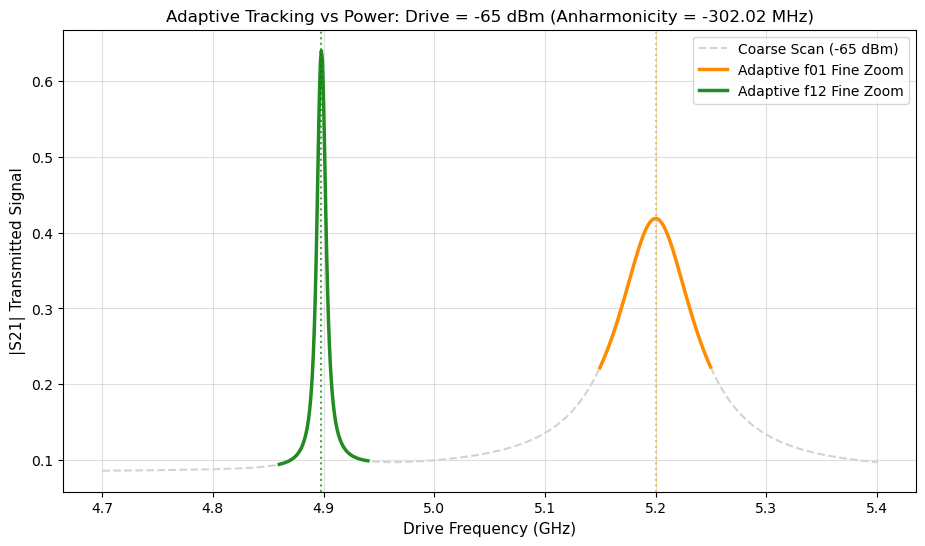

In [22]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# ============================================================
# ADAPTIVE SPECTROSCOPY WITH REAL DBM POWER INPUT
# ============================================================
class AdaptiveTransmonSpectroscopy:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, alpha_ghz=-0.3, g_mhz=30, Q=2000, N=10):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.alpha = alpha_ghz * 2 * np.pi
        self.g = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.chi = (self.g**2) / (self.wq - self.wc)
        
        # Operators
        self.a = qt.tensor(qt.qeye(3), qt.destroy(N))
        self.b = qt.tensor(qt.destroy(3), qt.qeye(N))
        self.n = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0/10000) * self.b]
        
        # Power Conversion Calibration (Same as Brute Force)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in Rotating Frame
        H = (self.wc - wr) * self.n + (self.wq - wd) * self.nb
        H += (self.alpha * 2.0 / 2.0) * self.nb * (self.nb - 1) # Matrix scaling fix
        H += self.chi * self.n * self.nb
        H += amp_r * (self.a + self.a.dag()) + amp_q * (self.b + self.b.dag())
        
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        return np.abs(1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r)))

# Initialize Simulation Object
sim = AdaptiveTransmonSpectroscopy()

# ============================================================
# CHOOSE YOUR DRIVE POWER HERE (Just like Brute Force!)
# Try shifting between: -90, -80, or -70
# ============================================================
readout_f = 6.000125
readout_p = -100
drive_p = -65   # <--- CHANGES EXPERIMENTAL POWER DYNAMICS DIRECTLY

# ------------------------------------------------------------
# STEP 1: COARSE GLOBAL SCAN
# ------------------------------------------------------------
coarse_freqs = np.linspace(4.7, 5.4, 200)
coarse_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in coarse_freqs])

# Pure peak tracking without signal inversion
coarse_peaks, _ = find_peaks(coarse_s21, prominence=0.01)

print(f"Coarse Scan done. Drive Power: {drive_p} dBm. Found {len(coarse_peaks)} features.")

# ------------------------------------------------------------
# STEP 2 & 3: ADAPTIVE REGION TRACKING
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))
plt.plot(coarse_freqs, coarse_s21, label=f'Coarse Scan ({drive_p} dBm)', color='lightgray', linestyle='--')
if len(coarse_peaks) >= 1:
    # Anchor f01 target point near 5.2 GHz
    f01_estimated = coarse_freqs[coarse_peaks[np.argmin(np.abs(coarse_freqs[coarse_peaks] - 5.2))]]
    
    # Adaptive Fine Window 1: Qubit f01
    f01_fine_range = np.linspace(f01_estimated - 0.05, f01_estimated + 0.05, 100)
    f01_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f01_fine_range])
    f01_actual = f01_fine_range[np.argmax(f01_fine_s21)]
    
    # Adaptive Fine Window 2: Secondary f12 based on dynamic physical spacing
    f12_predicted = f01_actual - 0.300
    f12_fine_range = np.linspace(f12_predicted - 0.04, f12_predicted + 0.04, 100)
    f12_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f12_fine_range])
    f12_actual = f12_fine_range[np.argmax(f12_fine_s21)]
    
    # Plotting targeted patches
    plt.plot(f01_fine_range, f01_fine_s21, label='Adaptive f01 Fine Zoom', color='darkorange', linewidth=2.5)
    plt.plot(f12_fine_range, f12_fine_s21, label='Adaptive f12 Fine Zoom', color='forestgreen', linewidth=2.5)
    
    calculated_alpha = (f12_actual - f01_actual) * 1000
    plt.title(f"Adaptive Tracking vs Power: Drive = {drive_p} dBm (Anharmonicity = {calculated_alpha:.2f} MHz)", fontsize=12)
    plt.axvline(f01_actual, color='orange', linestyle=':', alpha=0.7)
    plt.axvline(f12_actual, color='green', linestyle=':', alpha=0.7)
    
    print(f"Adaptive Lock Target -> f01: {f01_actual:.4f} GHz, f12: {f12_actual:.4f} GHz")
else:
    plt.title(f"3-Level Transmon Spectroscopy (Adaptive Sweep): Drive = {drive_p} dBm (Linear Regime)", fontsize=12)
plt.xlabel("Drive Frequency (GHz)", fontsize=11)
plt.ylabel("|S21| Transmitted Signal", fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_adaptive_sweep_-65dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Coarse Scan done. Drive Power: -60 dBm. Found 2 features.
Adaptive Lock Target -> f01: 5.2000 GHz, f12: 4.8948 GHz


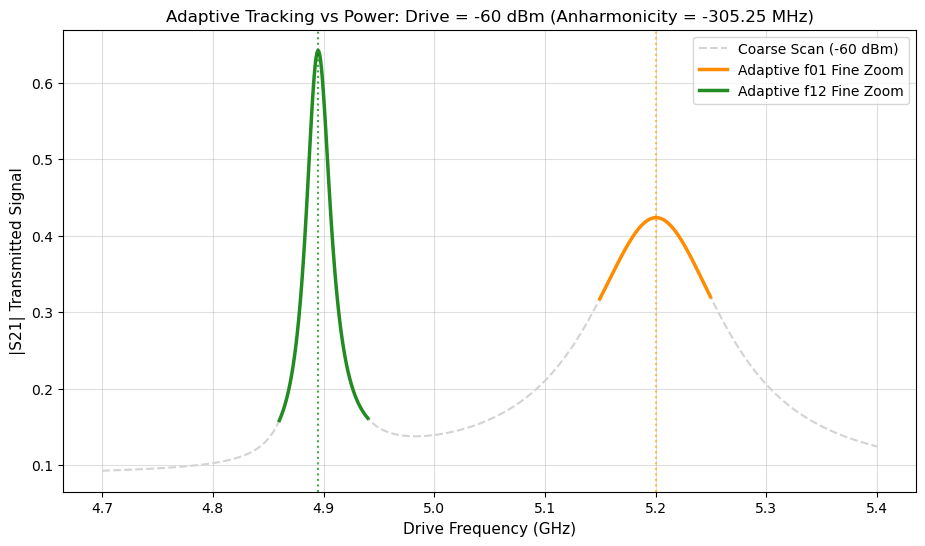

In [21]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# ============================================================
# ADAPTIVE SPECTROSCOPY WITH REAL DBM POWER INPUT
# ============================================================
class AdaptiveTransmonSpectroscopy:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, alpha_ghz=-0.3, g_mhz=30, Q=2000, N=10):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.alpha = alpha_ghz * 2 * np.pi
        self.g = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.chi = (self.g**2) / (self.wq - self.wc)
        
        # Operators
        self.a = qt.tensor(qt.qeye(3), qt.destroy(N))
        self.b = qt.tensor(qt.destroy(3), qt.qeye(N))
        self.n = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0/10000) * self.b]
        
        # Power Conversion Calibration (Same as Brute Force)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in Rotating Frame
        H = (self.wc - wr) * self.n + (self.wq - wd) * self.nb
        H += (self.alpha * 2.0 / 2.0) * self.nb * (self.nb - 1) # Matrix scaling fix
        H += self.chi * self.n * self.nb
        H += amp_r * (self.a + self.a.dag()) + amp_q * (self.b + self.b.dag())
        
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        return np.abs(1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r)))

# Initialize Simulation Object
sim = AdaptiveTransmonSpectroscopy()

# ============================================================
# CHOOSE YOUR DRIVE POWER HERE (Just like Brute Force!)
# Try shifting between: -90, -80, or -70
# ============================================================
readout_f = 6.000125
readout_p = -100
drive_p = -60   # <--- CHANGES EXPERIMENTAL POWER DYNAMICS DIRECTLY

# ------------------------------------------------------------
# STEP 1: COARSE GLOBAL SCAN
# ------------------------------------------------------------
coarse_freqs = np.linspace(4.7, 5.4, 200)
coarse_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in coarse_freqs])

# Pure peak tracking without signal inversion
coarse_peaks, _ = find_peaks(coarse_s21, prominence=0.01)

print(f"Coarse Scan done. Drive Power: {drive_p} dBm. Found {len(coarse_peaks)} features.")

# ------------------------------------------------------------
# STEP 2 & 3: ADAPTIVE REGION TRACKING
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))
plt.plot(coarse_freqs, coarse_s21, label=f'Coarse Scan ({drive_p} dBm)', color='lightgray', linestyle='--')
if len(coarse_peaks) >= 1:
    # Anchor f01 target point near 5.2 GHz
    f01_estimated = coarse_freqs[coarse_peaks[np.argmin(np.abs(coarse_freqs[coarse_peaks] - 5.2))]]
    
    # Adaptive Fine Window 1: Qubit f01
    f01_fine_range = np.linspace(f01_estimated - 0.05, f01_estimated + 0.05, 100)
    f01_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f01_fine_range])
    f01_actual = f01_fine_range[np.argmax(f01_fine_s21)]
    
    # Adaptive Fine Window 2: Secondary f12 based on dynamic physical spacing
    f12_predicted = f01_actual - 0.300
    f12_fine_range = np.linspace(f12_predicted - 0.04, f12_predicted + 0.04, 100)
    f12_fine_s21 = np.array([sim.get_s21(readout_f, readout_p, f, drive_p) for f in f12_fine_range])
    f12_actual = f12_fine_range[np.argmax(f12_fine_s21)]
    
    # Plotting targeted patches
    plt.plot(f01_fine_range, f01_fine_s21, label='Adaptive f01 Fine Zoom', color='darkorange', linewidth=2.5)
    plt.plot(f12_fine_range, f12_fine_s21, label='Adaptive f12 Fine Zoom', color='forestgreen', linewidth=2.5)
    
    calculated_alpha = (f12_actual - f01_actual) * 1000
    plt.title(f"Adaptive Tracking vs Power: Drive = {drive_p} dBm (Anharmonicity = {calculated_alpha:.2f} MHz)", fontsize=12)
    plt.axvline(f01_actual, color='orange', linestyle=':', alpha=0.7)
    plt.axvline(f12_actual, color='green', linestyle=':', alpha=0.7)
    
    print(f"Adaptive Lock Target -> f01: {f01_actual:.4f} GHz, f12: {f12_actual:.4f} GHz")
else:
    plt.title(f"3-Level Transmon Spectroscopy (Adaptive Sweep): Drive = {drive_p} dBm (Linear Regime)", fontsize=12)
plt.xlabel("Drive Frequency (GHz)", fontsize=11)
plt.ylabel("|S21| Transmitted Signal", fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_adaptive_sweep_-60dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()